In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib
import seaborn as sns
import os

# set the font size
plt.rcParams.update({'font.size': 7})
# set Helvetica globally
plt.rcParams['font.family'] = 'Helvetica'

base_plot_folder = "../plots/17_conceptual_plots/"
# create folder if it does not exist
if not os.path.exists(base_plot_folder):
    os.makedirs(base_plot_folder)

In [148]:
df = pd.DataFrame(columns=["A", "B", "C", "D", "E"], index=range(0,5))
df = df.fillna(0)

In [149]:
# add 1 on the diagonal of the dataframe
for i in range(0,len(df)):
    df.iloc[i,i] = 1

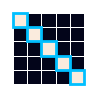

In [150]:
plt.figure(figsize=(1,1))
ax = sns.heatmap(df, cmap="rocket", cbar=False, linewidths=0.5, linecolor="white", square=True)

for i in range(0,len(df)):
    box_color = "deepskyblue"
    rect = patches.Rectangle((i, i), 1, 1, linewidth=2, edgecolor=box_color, facecolor='none')
    ax.add_patch(rect)

plt.xlim(len(df)+0.2, -0.2)
plt.ylim(-0.2,len(df)+0.2)
plt.xticks([])
plt.yticks([])
plt.savefig(base_plot_folder + "heatmap_target.svg", dpi=300, bbox_inches='tight', transparent=True)

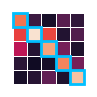

In [151]:
# add gaussian noise to the dataframe
noise = np.random.normal(0, 0.2, df.shape)
for i in range(0,len(df)):
    for j in range(0,len(df)):
        if i != j and noise[i,j] < 0:
            noise[i,j] = -noise[i,j]
        elif i == j and noise[i,j] >= 0:
            noise[i,j] = -noise[i,j]

df = df + noise

plt.figure(figsize=(1,1))
ax = sns.heatmap(df, cmap="rocket", cbar=False, linewidths=0.5, linecolor="white", square=True, vmin=0, vmax=1)

for i in range(0,len(df)):
    box_color = "deepskyblue"
    rect = patches.Rectangle((i, i), 1, 1, linewidth=2, edgecolor=box_color, facecolor='none')
    ax.add_patch(rect)

plt.xlim(len(df)+0.2, -0.2)
plt.ylim(-0.2,len(df)+0.2)
plt.xticks([])
plt.yticks([])
plt.savefig(base_plot_folder + "heatmap_prediction.svg", dpi=300, bbox_inches='tight', transparent=True)

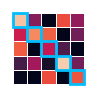

In [152]:
# add gaussian noise to the dataframe
df = df + np.random.normal(0, 0.2, df.shape)

plt.figure(figsize=(1,1))
ax = sns.heatmap(df, cmap="rocket", cbar=False, linewidths=0.5, linecolor="white", square=True, vmin=0, vmax=1)

for i in range(0,len(df)):
    box_color = "deepskyblue"
    rect = patches.Rectangle((i, i), 1, 1, linewidth=2, edgecolor=box_color, facecolor='none')
    ax.add_patch(rect)

plt.xlim(len(df)+0.2, -0.2)
plt.ylim(-0.2,len(df)+0.2)

plt.xticks([])
plt.yticks([])
plt.savefig(base_plot_folder + "heatmap_measurement.svg", dpi=300, bbox_inches='tight', transparent=True)

In [168]:
steps = [1/6.0 * i for i in range(0,7)]
# shuffle steps
np.random.shuffle(steps)

In [170]:
steps

[0.8333333333333333,
 0.5,
 0.0,
 0.3333333333333333,
 1.0,
 0.6666666666666666,
 0.16666666666666666]

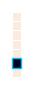

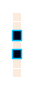

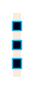

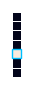

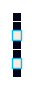

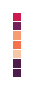

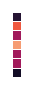

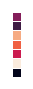

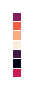

In [182]:
df = pd.DataFrame(columns=["A", "B", "C", "D", "E", "F", "G", "H", "I"], index=range(0,7))
df = df.fillna(0)

steps = [1/6.0 * i for i in range(0,7)]


df.iloc[:,0] = [1, 0, 1, 1, 1, 1, 1]
df.iloc[:,1] = [1, 1, 0, 1, 0, 1, 1]
df.iloc[:,2] = [1, 0, 1, 0, 1, 0, 1]
df.iloc[:,3] = [0, 0, 1, 0, 0, 0, 0]
df.iloc[:,4] = [0, 1, 0, 0, 1, 0, 0]
df.iloc[:,5] = [0.2, 0.2, 0.9, 0.7, 0.8, 0.3, 0.5]
df.iloc[:,6] = [0.05, 0.4, 0.4, 0.8, 0.4, 0.65, 0.1]
# shuffle steps
np.random.shuffle(steps)
df.iloc[:,7] = steps
# shuffle steps
np.random.shuffle(steps)
df.iloc[:,8] = steps

for i, column in enumerate(df.columns):
    plt.figure(figsize=(0.35,0.9))
    ax = sns.heatmap(df[[column]], cmap="rocket", cbar=False, linewidths=0.5, linecolor="white", square=True, vmin=0, vmax=1)

    # count the number of 1s and 0s in the column
    number_of_ones = len(df[df[column] == 1])
    number_of_zeros = len(df[df[column] == 0])
    box_color = "deepskyblue"
    for j in range(0, len(df[[column]])):
        if number_of_ones > number_of_zeros:
            if df.iloc[j][column] == 0:
                rect = patches.Rectangle((0, j), 1, 1, linewidth=1, edgecolor=box_color, facecolor='none')
                ax.add_patch(rect)
        elif number_of_ones < number_of_zeros:
            if df.iloc[j][column] == 1:
                rect = patches.Rectangle((0, j), 1, 1, linewidth=1, edgecolor=box_color, facecolor='none')
                ax.add_patch(rect)
    
    plt.xticks([])
    plt.yticks([])
    
    plt.xlim(-0.2, 1.2)
    plt.ylim(-0.2,len(df[[column]])+0.2)
    
    
    plt.savefig(base_plot_folder + f"design_pattern_types_{i}.svg", dpi=300, bbox_inches='tight', transparent=True)